### **LIVER DISEASE PREDICTION USING MACHINE LEARNING **

### DATA UNDERSTANDING
Description:

The Liver Patient Dataset contains medical records of patients collected from North-East Andhra Pradesh, India. The dataset includes attributes such as age, gender, bilirubin levels, liver enzymes, protein levels, and albumin-globulin ratio. The target variable indicates whether a patient has liver disease or not.

Notes:

Total records: 583

Features: 11

Target column: Disease (1 = Liver Disease, 0 = No Disease)

Domain: Healthcare

This step helps in understanding the structure and nature of the dataset before applying preprocessing and machine learning algorithms.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df= pd.read_csv("Indian Liver Patient Dataset.csv", header=None)
df


,0,1,2,3,4,5,6,7,8,9,10
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [16]:
df.shape

(583, 11)

In [17]:
columns=['Age','Gender','Total_Bilirubin','Direct_Bilirubin','Alkaline_Phosphotase','Alamine_Aminotransferase','Aspartate_Aminotransferase','Total_Protiens','Albumin','Albumin_and_Globulin_Ratio','Disease']

In [18]:
df = pd.read_csv("Indian Liver Patient Dataset.csv",header=None,names=columns)
df


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Disease
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [19]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Disease
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [20]:
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Disease'],
      dtype='object')

In [21]:
df.shape

(583, 11)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Disease                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [23]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Disease
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [24]:
df['Disease'].value_counts()


,count
Disease,
1,416
2,167


### MISSING VALUE HANDLING
Missing values were identified using isnull().sum(). Since this is a medical dataset, missing values in numerical columns were handled using median imputation to avoid the effect of outliers. Categorical values such as Gender were filled using mode.

### Notes:
Numerical columns: filled with median
Categorical columns: filled with mode
After imputation, no missing values remained in the dataset
This ensures that the dataset is complete and suitable for machine learning models.

In [25]:
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [26]:
df['Albumin_and_Globulin_Ratio'].value_counts()

,count
Albumin_and_Globulin_Ratio,
1.00,106
0.80,65
0.90,59
0.70,53
1.10,46
...,...
1.72,1
0.46,1
0.39,1


Missing values in Albumin and Globulin Ratio column are filled using mean/median.Mean/median is used because it preserves data distribution and avoids data loss.

In [27]:
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].median())


In [28]:
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  583 non-null    float64
 10  Disease                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [30]:
df

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Disease
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


###EXPLORATORY DATA ANALYSIS (EDA)
Exploratory Data Analysis (EDA) was performed to analyze the distribution of features, identify missing values, and understand relationships between variables. Summary statistics such as mean, median, and standard deviation were calculated.

### Notes:
* Used df.info(), df.describe(), and df.head().
* Checked data types of each column
* Visualized data using plots like histograms and correlation heatmaps
* EDA helps to identify patterns, anomalies, and important relationships in the dataset.
*   List item







### COUNTPLOT OF TARGET VARIABLE:
Shows number of liver vs non-liver patients.
To check class imbalance.

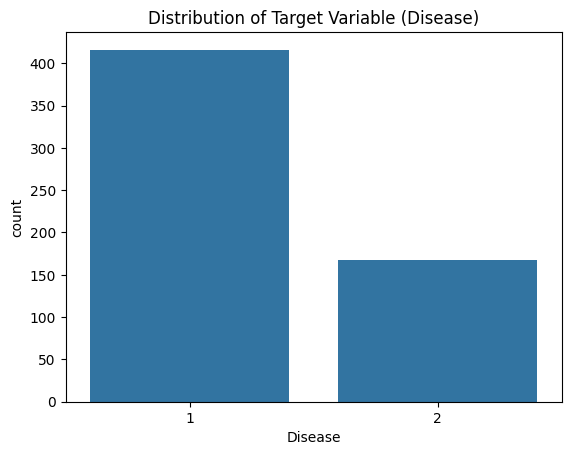

,proportion
Disease,
1,71.35506
2,28.64494


In [31]:
sns.countplot(x='Disease', data=df)
plt.title("Distribution of Target Variable (Disease)")
plt.show()

df['Disease'].value_counts(normalize=True) * 100


GENDER VS LIVER DISEASE:




This count plot shows the distribution of liver disease cases based on gender. The x-axis represents Gender (Male and Female) and the y-axis represents the number of patients (count). The plot is divided by the target variable Disease where:

Disease = 1 → Patient has liver disease

Disease = 2 → Patient does not have liver disease


* Male patients are more affected by liver disease than female patients.The number of male patients with liver disease (Disease = 1) is significantly higher compared to female patients.

* Female patients show fewer liver disease cases overall.Both liver disease and non-liver disease counts are lower for females when compared to males.

* Class imbalance is visible between genders.The dataset contains more male records than female records, which may influence the models predictions.

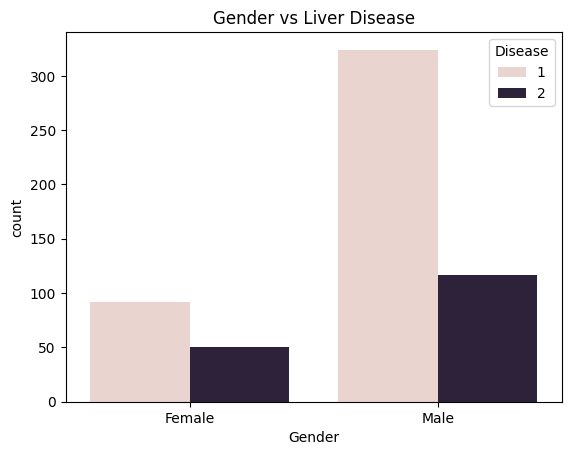

In [32]:
sns.countplot(x='Gender',hue='Disease',data=df)
plt.title("Gender vs Liver Disease")
plt.show()


#AGE DISTRIBUTION OF PATIENTS:

This histogram shows the distribution of patients across different age groups. Most patients are in the age range of 30 to 60 years, indicating that liver disease cases are more common among middle-aged adults. The KDE curve shows that the age data follows an approximately normal distribution.

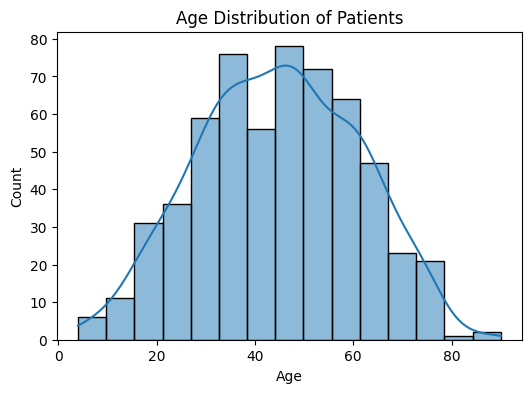

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution of Patients")
plt.show()


### **AGE VS DISEASE(BOX PLOT)**:
This box plot compares the age distribution between patients with liver disease (Disease = 1) and without liver disease (Disease = 2). Patients with liver disease tend to have a slightly higher median age compared to non-liver disease patients. This indicates that age is an important factor in liver disease occurrence.

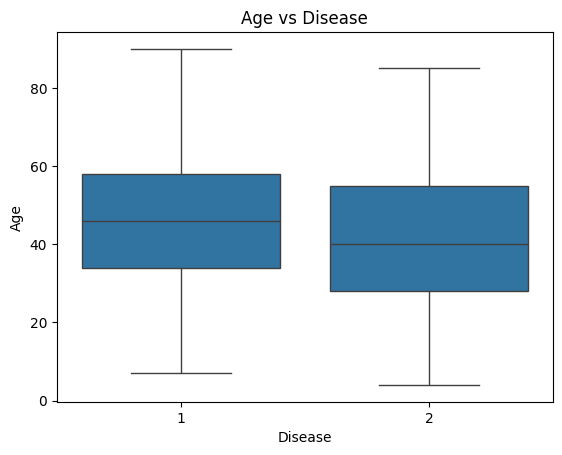

In [34]:
sns.boxplot(x='Disease', y='Age', data=df)
plt.title("Age vs Disease")
plt.show()


### **Univariate analysis for numerical columns:**

### **HISTOGRAM OF ALL NUMERICAL FEATURES**:
These histograms illustrate the distribution of all numerical features in the dataset. Several attributes such as bilirubin and enzyme levels are right-skewed, indicating outliers, while age and protein features are more evenly distributed. This analysis helps in deciding preprocessing steps like scaling and outlier treatment.

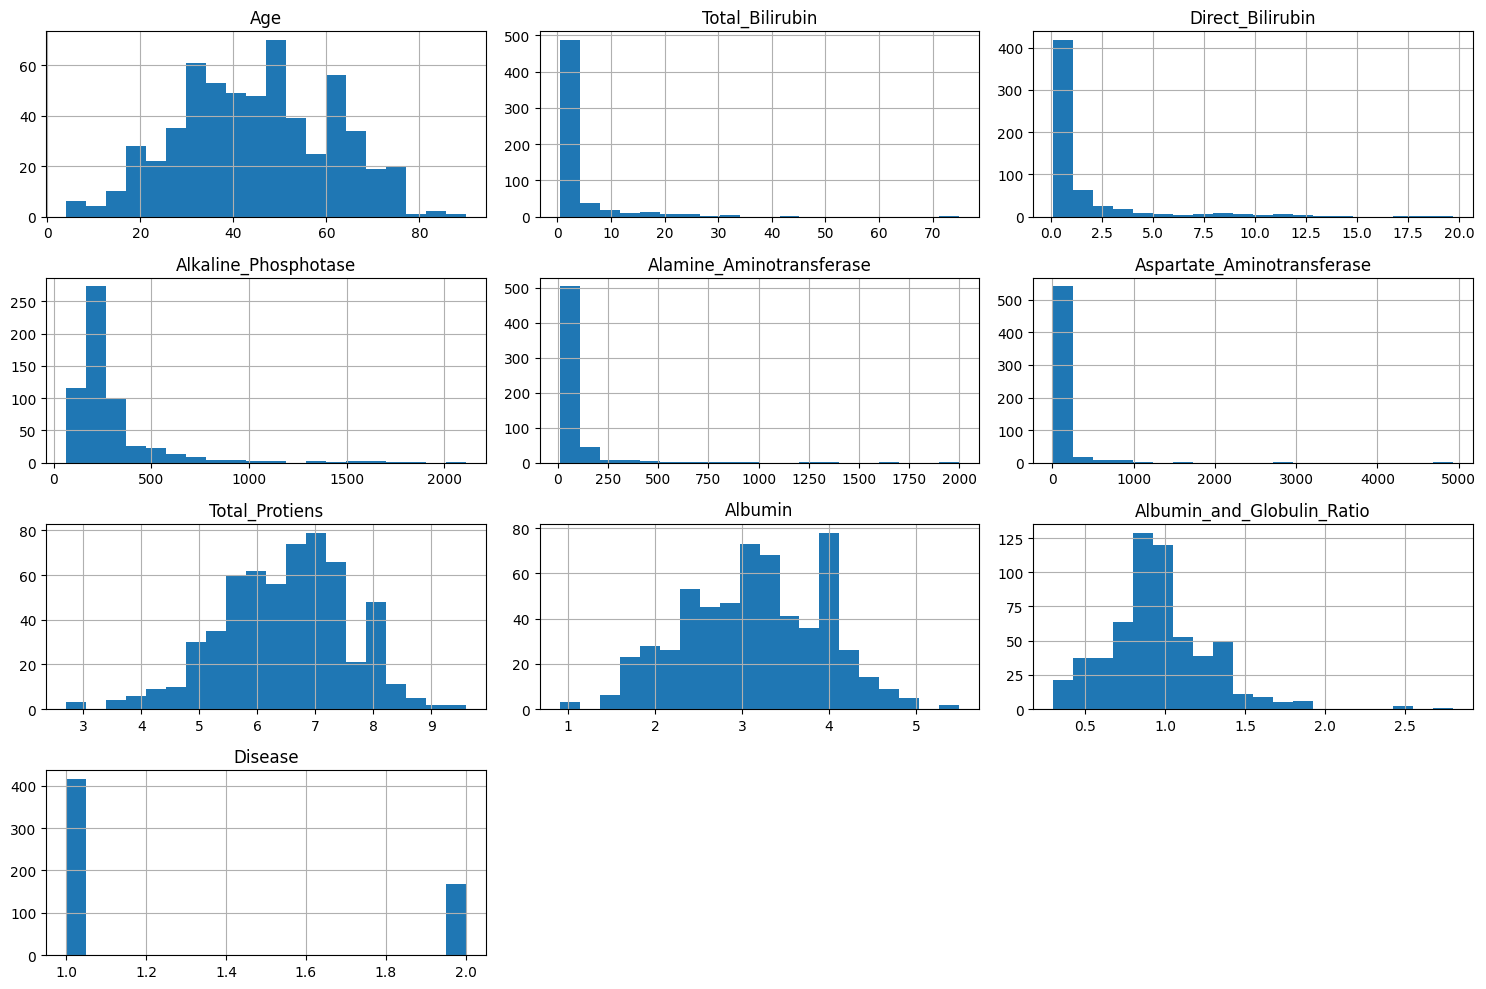

In [35]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()


In [36]:
num_cols =df.select_dtypes(include='number').columns
cat_cols =df.select_dtypes(include='object').columns


### **DISTRIBUTION OF NUMERICAL FEATURES**:
These distribution plots help in understanding the spread and skewness of numerical variables. Several features such as bilirubin and enzyme levels are right-skewed with outliers, while age and protein-related features show relatively normal distributions. This insight guides preprocessing steps like outlier handling and feature scaling.

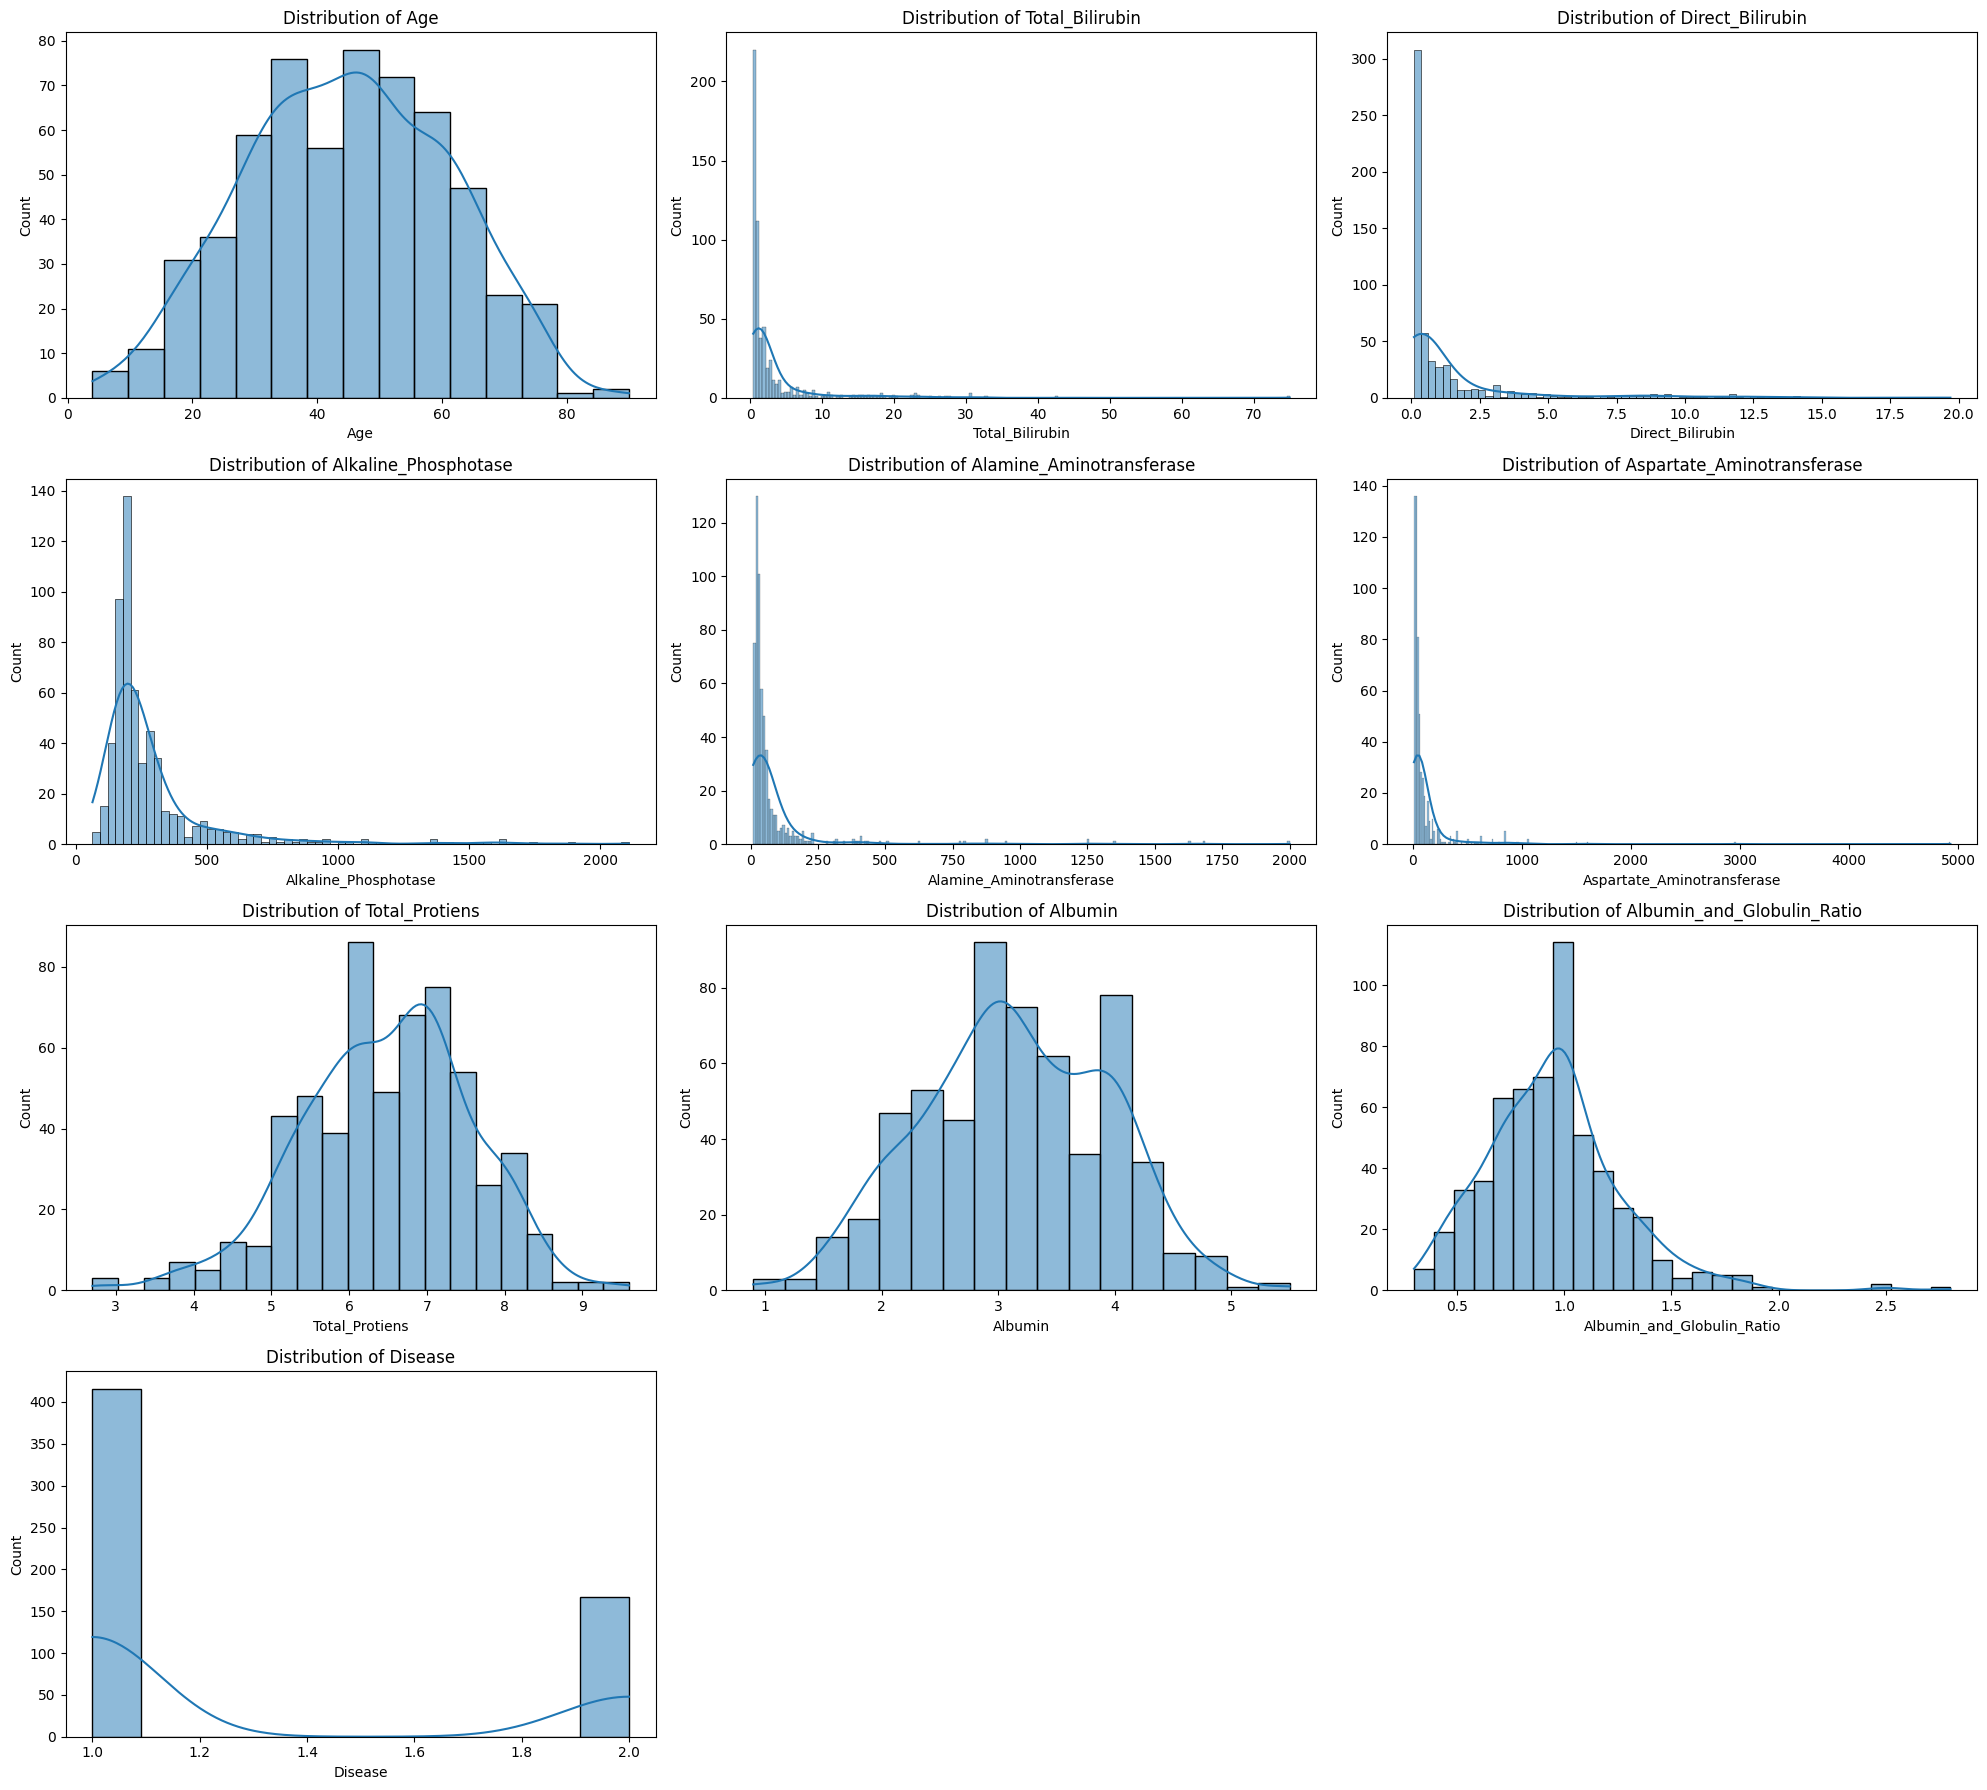

In [37]:
plt.figure(figsize=(20, 18))
pos = 1
for col in num_cols:
    plt.subplot(4, 3, pos)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    pos += 1
plt.tight_layout()
plt.show()


### **PAIRWISE FEATURE RELATIONSHIP:**:
The pair plot displays pairwise relationships among numerical features and their distributions. It reveals correlations among liver-related attributes such as bilirubin and enzyme levels and shows overlapping classes, indicating the need for machine learning models for better classification.

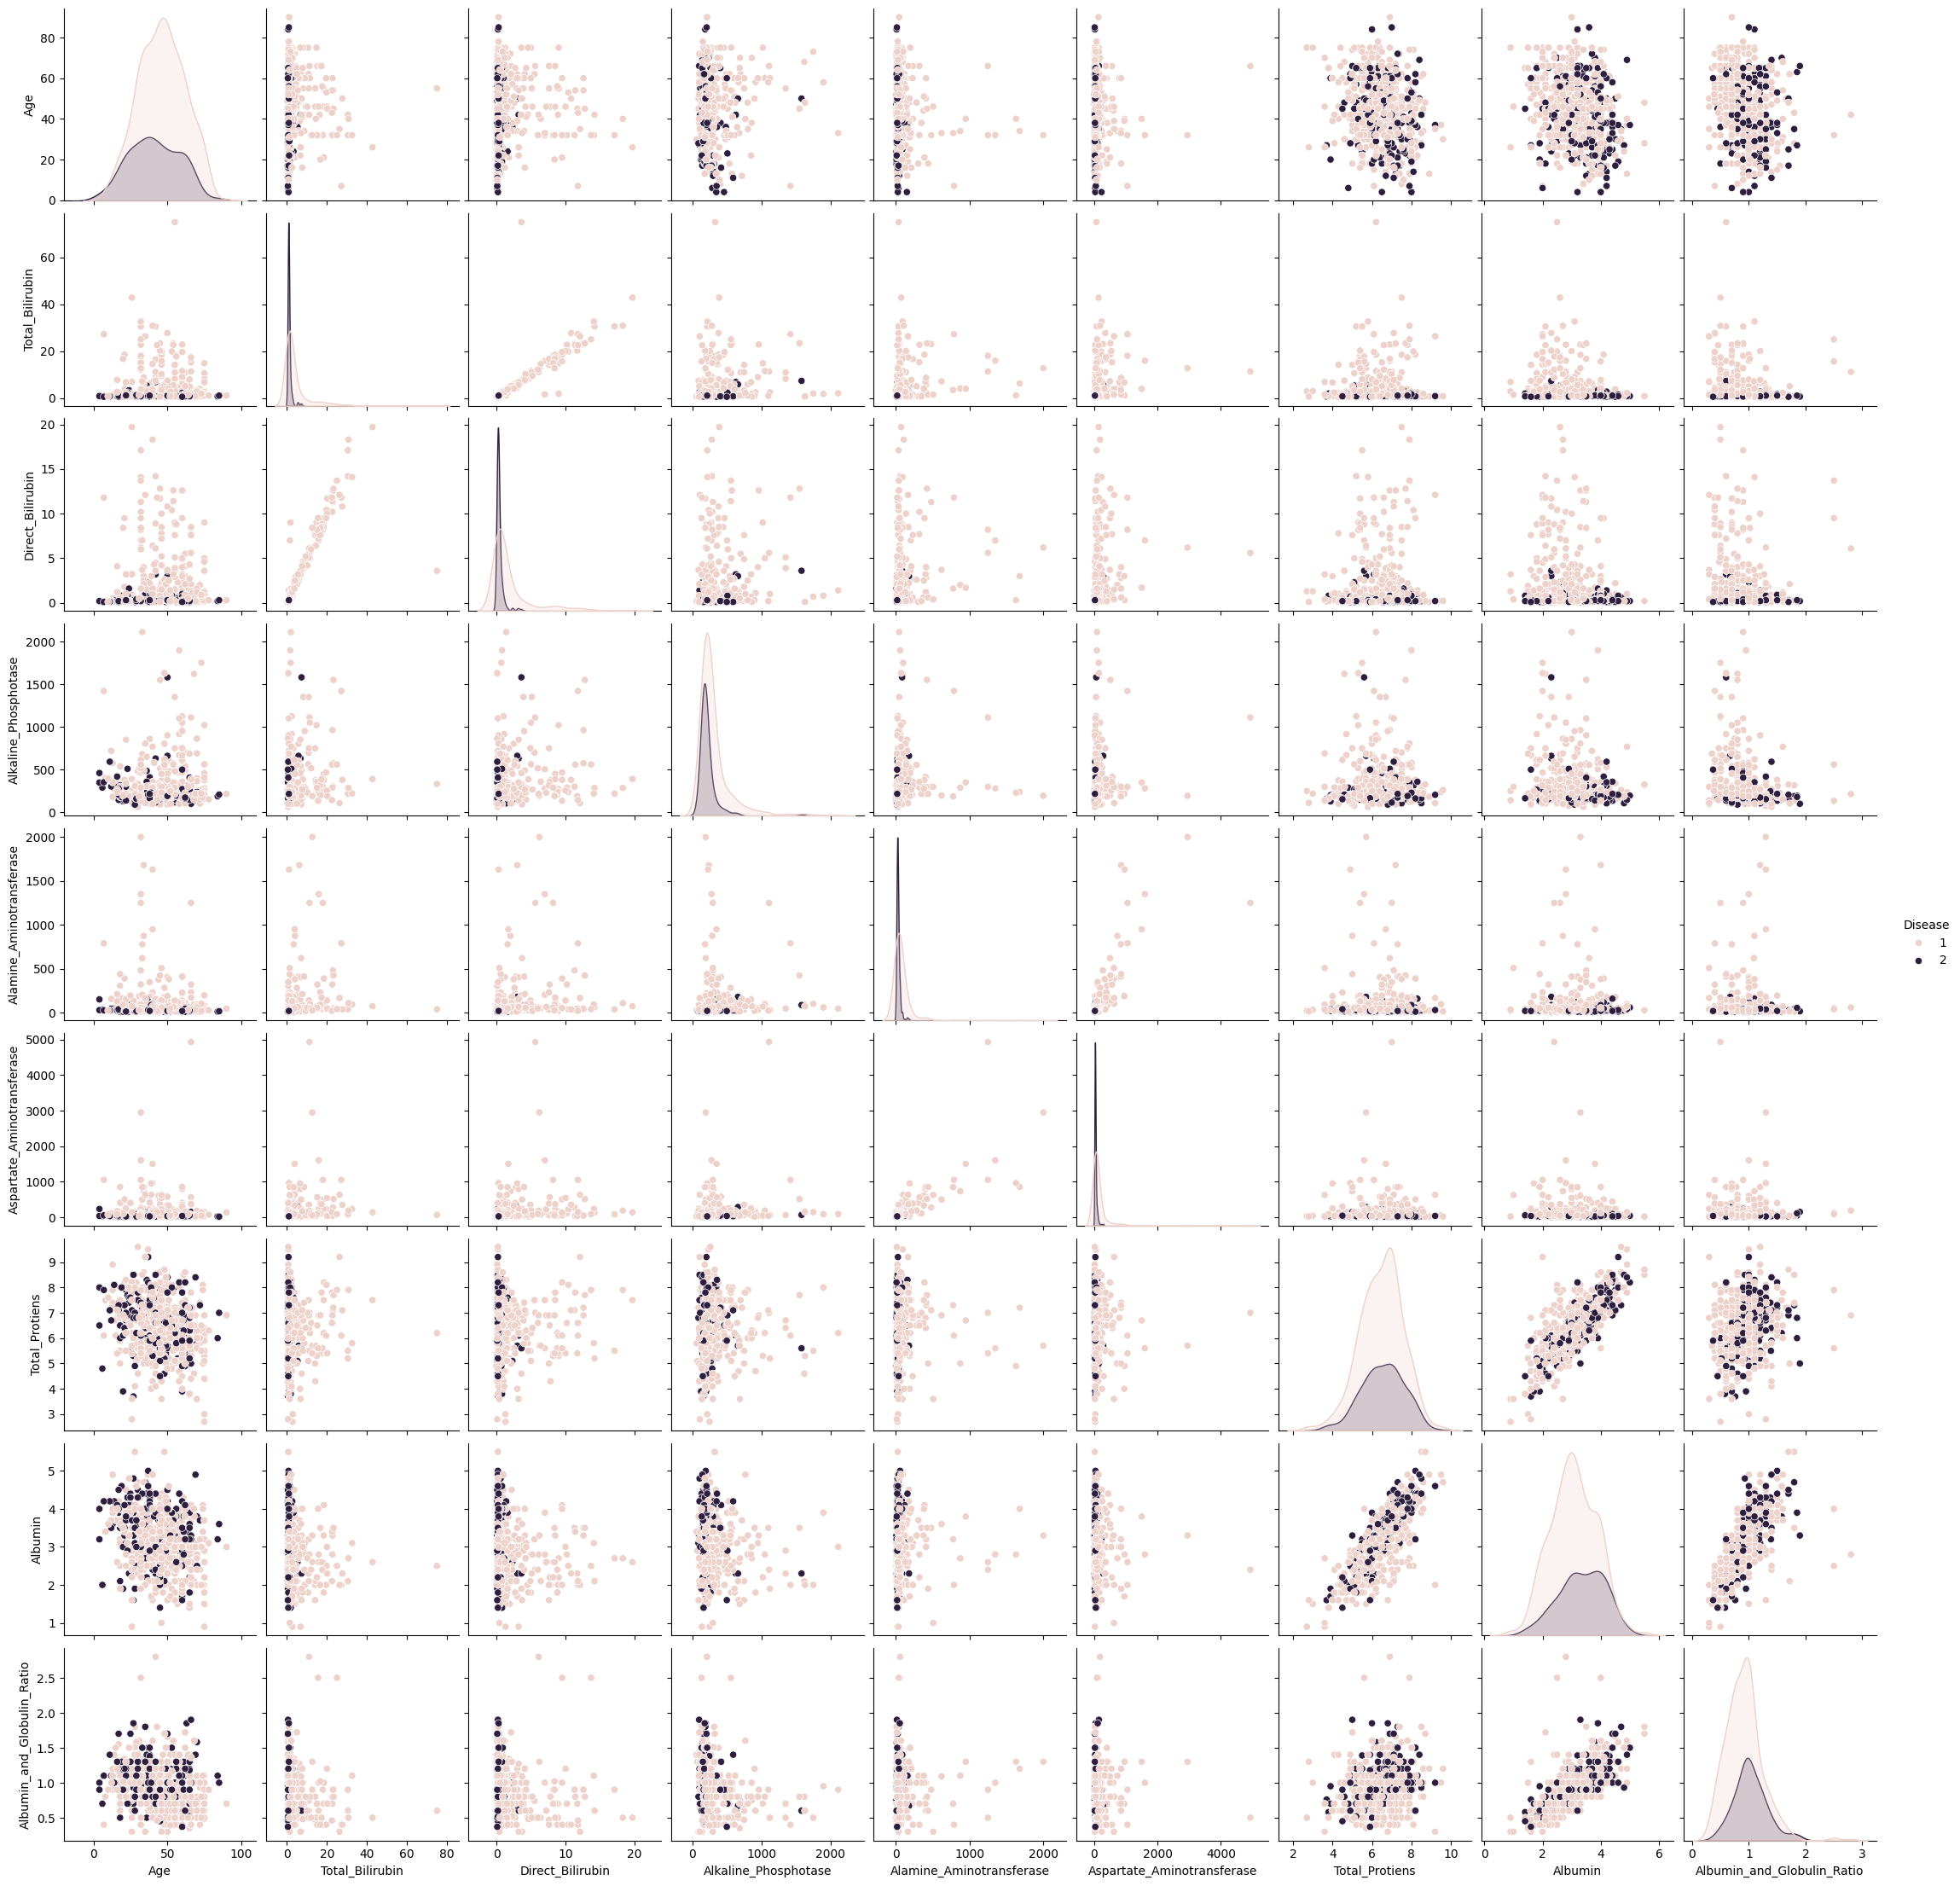

In [38]:
sns.pairplot(df, hue='Disease')
plt.show()


### **TOTAL BILIRUBIN VS DISEASE**:
* This violin plot compares the distribution of Total Bilirubin levels between patients with liver disease (Disease = 1) and patients without liver disease (Disease = 0).
* The violin plot shows that patients with liver disease have significantly higher and more variable Total Bilirubin levels than non-liver disease patients. This indicates that Total Bilirubin is an important feature for predicting liver disease.

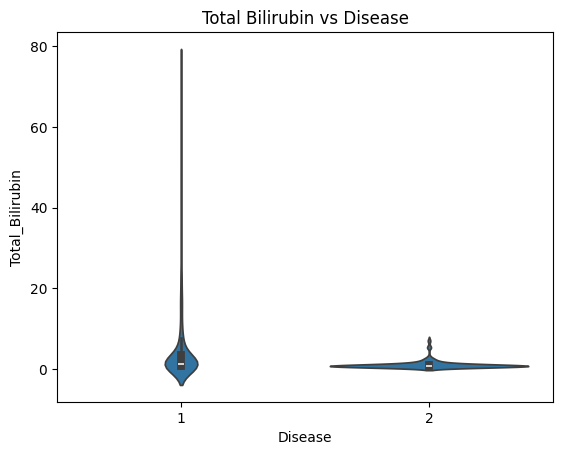

In [39]:
sns.violinplot(x='Disease', y='Total_Bilirubin', data=df)
plt.title("Total Bilirubin vs Disease")
plt.show()


### **OUTLIERS VISUALIZATION USING BOXPLOTS**:
In this step, boxplots are used to visualize the presence of outliers across all numerical features such as Total Bilirubin, Direct Bilirubin, Alkaline Phosphatase, ALT, AST, Total Proteins, Albumin, and Albumin & Globulin Ratio.

* The boxplots clearly show that several medical attributes, especially bilirubin and enzyme-related features, contain extreme values and long upper tails.

* These outliers represent patients with unusually high liver enzyme and bilirubin levels, which are medically meaningful and indicate severe liver conditions.
* Outliers were not removed or treated in this project because they carry important clinical information and are part of the natural variation in patient health data.


* Removing these values could result in loss of critical medical insights and may reduce the model’s ability to detect serious liver disease cases.



In [40]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols


Index(['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
       'Alamine_Aminotransferase', 'Aspartate_Aminotransferase',
       'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Disease'],
      dtype='object')

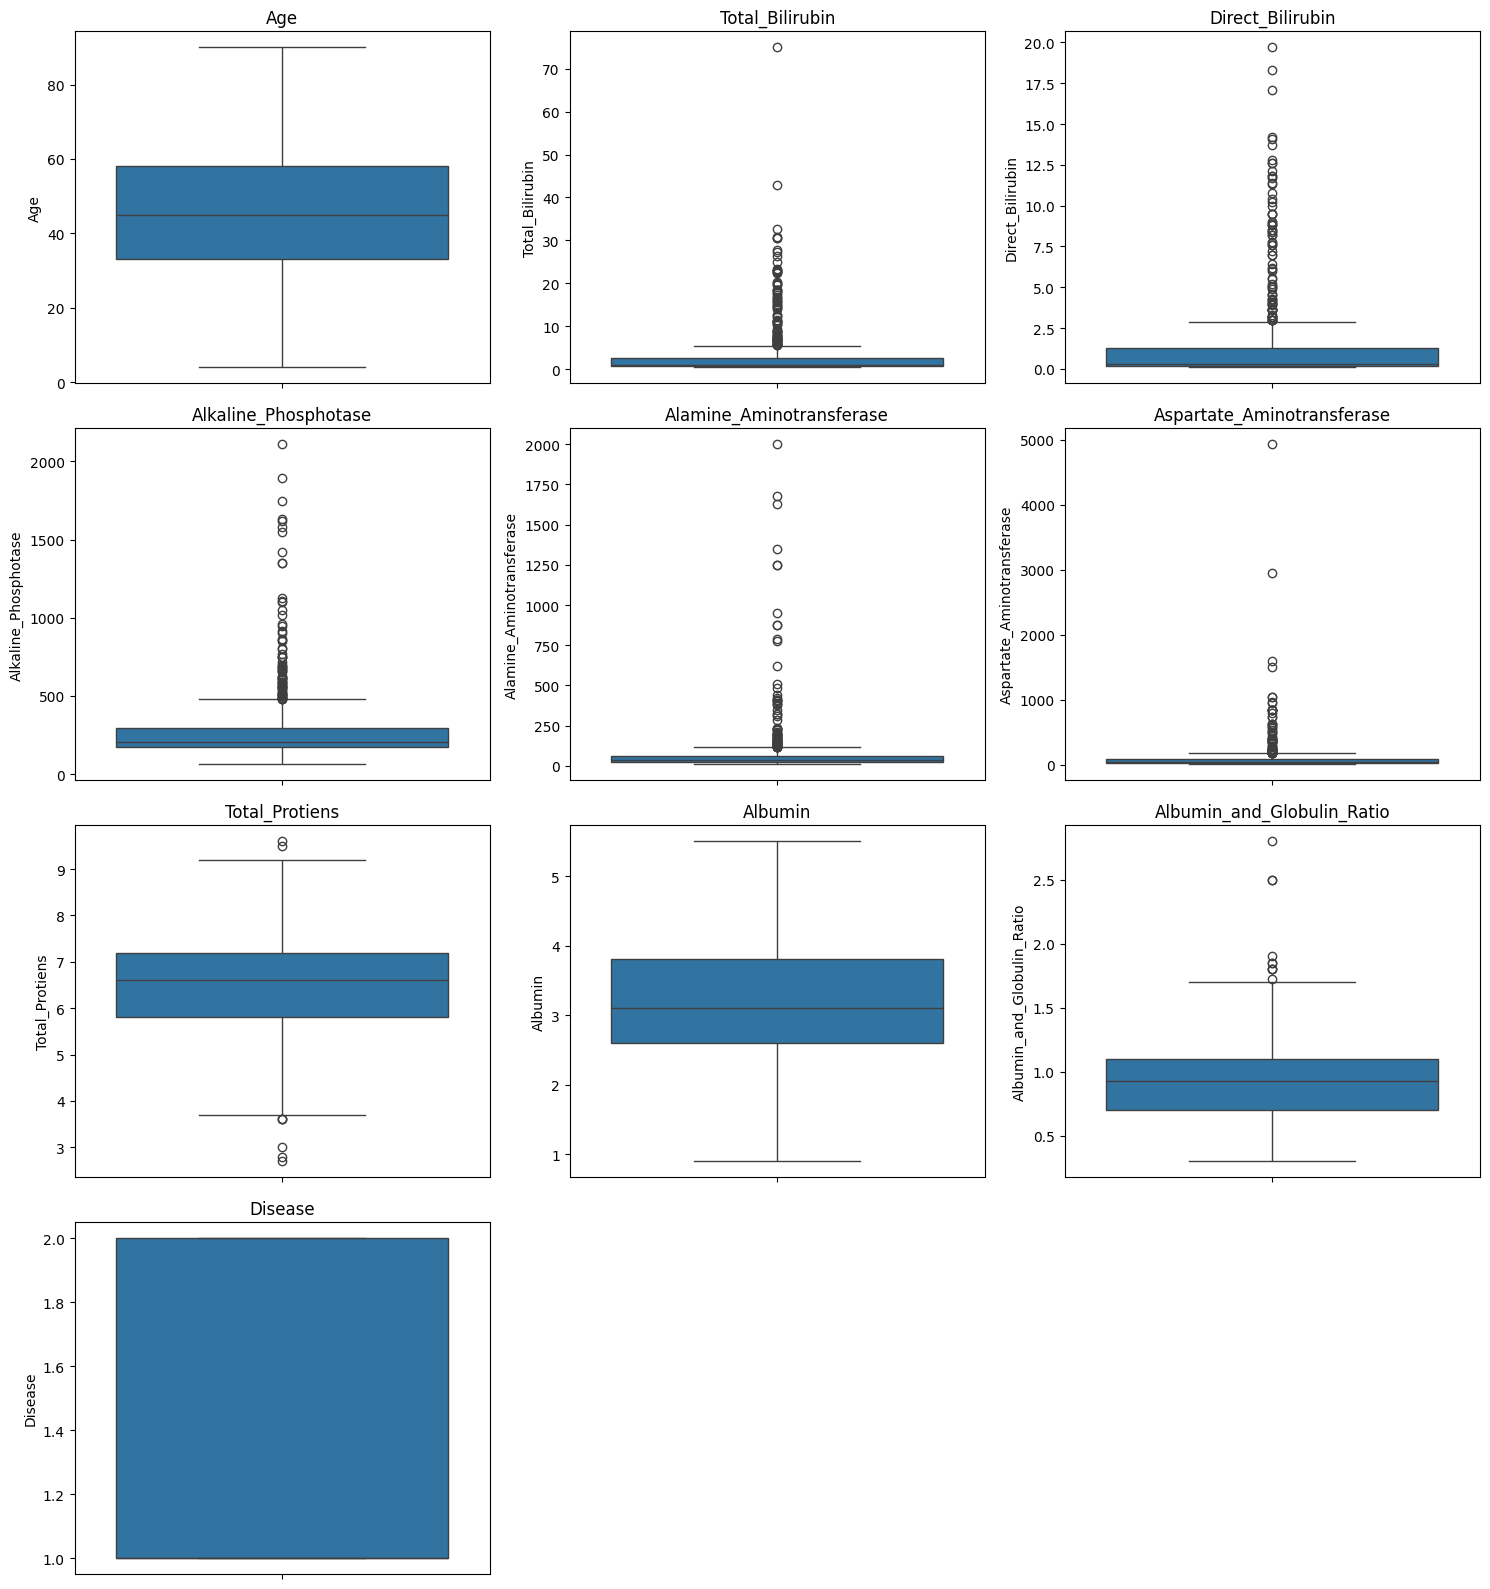

In [41]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


### ENCODING CATEGORICAL VARIABLES
The categorical feature Gender was converted into numerical form using label encoding where Male = 1 and Female = 0. Machine learning algorithms require numerical input, so encoding is necessary.

Gender column encoded
Ensures compatibility with ML models

In [42]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [43]:
df['Disease'] = df['Disease'].map({1: 1, 2: 0})


### **CORRELATION OF FEATURES WITH TARGET VARIABLE**
In this step, the correlation between each independent feature and the target variable Disease is calculated and visualized using a bar plot and a sorted correlation table.

* Direct Bilirubin (0.246) and Total Bilirubin (0.220) show the strongest positive correlation with liver disease, indicating that higher bilirubin levels are strongly associated with the presence of liver disease.
* The correlation analysis shows that bilirubin and enzyme-related features have the highest positive correlation with liver disease, while albumin and albumin globulin ratio have negative correlation
* Age and gender have weaker influence. This confirms the importance of biochemical attributes in predicting liver disease.








In [44]:
corr_target = df.corr()['Disease'].sort_values(ascending=False)
corr_target


,Disease
Disease,1.000000
Direct_Bilirubin,0.246046
Total_Bilirubin,0.220208
Alkaline_Phosphotase,0.184866
Alamine_Aminotransferase,0.163416
Aspartate_Aminotransferase,0.151934
Age,0.137351
Gender,0.082416
Total_Protiens,-0.035008
Albumin,-0.161388


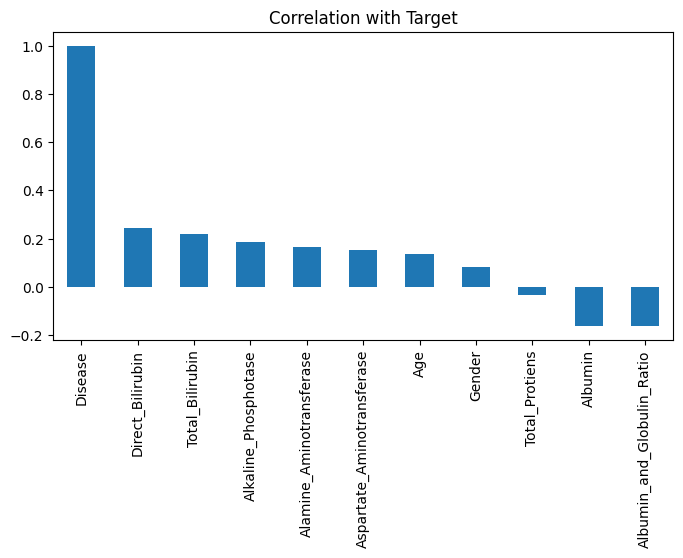

In [45]:
corr_target.plot(kind='bar', figsize=(8,4), title="Correlation with Target")
plt.show()


### **CORRELATION HEATMAP AND MULTICOLINEARITY ANALYSIS USING VIF**
In this step, a correlation heatmap and Variance Inflation Factor (VIF) analysis were used to examine the relationship among independent features and to detect multicollinearity.

* Strong positive correlations are observed between Total Bilirubin and Direct Bilirubin (0.87) ALT (Alamine Aminotransferase) and AST (Aspartate Aminotransferase) (0.79) Albumin and Total Proteins (0.78).
* These strong correlations indicate that several biochemical attributes are closely related, which is expected in liver function tests since many parameters are biologically dependent on each other.




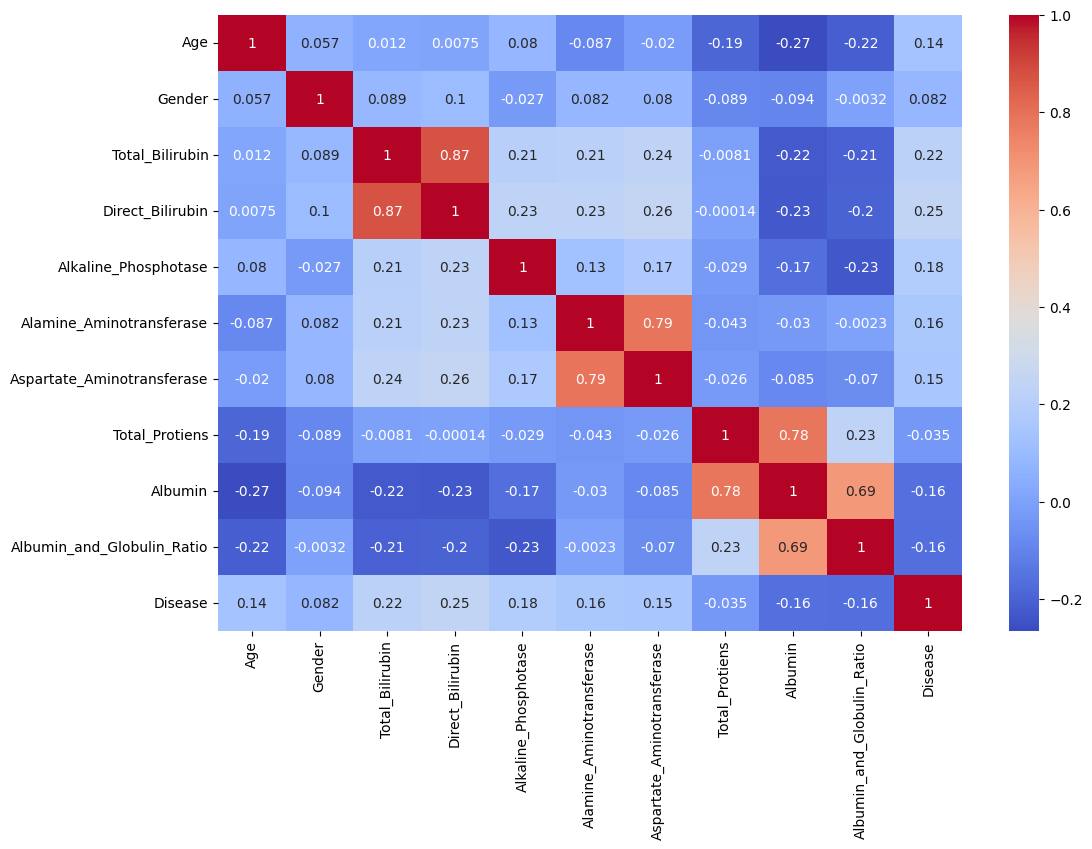

In [46]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [47]:
x = df.drop('Disease', axis=1)
y = df['Disease']


* Very high VIF values are observed for Albumin (133),Total, Proteins (102), Albumin and Globulin Ratio (26), Total Bilirubin and Direct Bilirubin (5–6).
* High VIF values confirm the presence of multicollinearity among
features.

### **Why Multicollinearity Was Not Removed in This Project:**
Medical significance of features:
All highly correlated variables represent important liver biomarkers. Removing them could lead to loss of valuable clinical information.

Project objective:
The aim of this project is classification (prediction of liver disease), not regression coefficient interpretation. Many machine learning models (such as Random Forest, Decision Tree, and KNN) are less sensitive to multicollinearity compared to linear regression.

Dataset size limitation:
Removing correlated features would further reduce the feature set and may negatively affect model performance.

Exploratory purpose:
The VIF and correlation analysis were performed mainly for understanding feature relationships, not for feature elimination.

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i)
                   for i in range(x.shape[1])]
vif_data.sort_values(by="VIF", ascending=False)


,Feature,VIF
8,Albumin,132.934799
7,Total_Protiens,101.823445
9,Albumin_and_Globulin_Ratio,25.686287
0,Age,7.812416
3,Direct_Bilirubin,5.736160
2,Total_Bilirubin,5.479227
1,Gender,4.087791
5,Alamine_Aminotransferase,3.308655
6,Aspartate_Aminotransferase,3.192716
4,Alkaline_Phosphotase,2.650264


### **FEATURE IMPORTANCE USING MUTUAL INFORMATION(MI SCORE)**

* Mutual Information scores were used to evaluate the importance of each feature with respect to the target variable.
* Enzyme and bilirubin-related features such as AST, Direct Bilirubin, ALT, and Total Bilirubin show the highest relevance for predicting liver disease, while gender and albumin contribute less.
* This confirms the importance of biochemical markers in the classification model.








In [49]:
from sklearn.feature_selection import mutual_info_classif

x = df.drop('Disease', axis=1)
y = df['Disease']

mi_scores = mutual_info_classif(x, y)
mi_df = pd.DataFrame({'Feature': x.columns, 'MI Score': mi_scores})
mi_df.sort_values(by='MI Score', ascending=False)


,Feature,MI Score
6,Aspartate_Aminotransferase,0.094955
5,Alamine_Aminotransferase,0.070332
0,Age,0.066536
2,Total_Bilirubin,0.062561
3,Direct_Bilirubin,0.048635
1,Gender,0.034089
4,Alkaline_Phosphotase,0.031713
8,Albumin,0.019782
7,Total_Protiens,0.015201
9,Albumin_and_Globulin_Ratio,0.000000


### FEATURE SCALING
StandardScaler was applied to normalize feature values so that all features are on the same scale. This is important for distance-based and gradient-based models such as Logistic Regression, SVM, and KNN.

### Notes:
* Mean = 0, Standard deviation = 1
* Prevents bias from large numerical ranges
* Improves model performance






In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


### TRAIN TEST SPLIT
The dataset was split into training and testing sets using an 80:20 ratio. Stratified sampling was applied to preserve class distribution.

### Notes:
* Training set: 80%
* Testing set: 20%
* Ensures fair model evaluation







In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y,test_size=0.2,random_state=42)


### MODEL BUILDING (MULTIPLE CLASSIFIERS)

### Models Used:
* Logistic Regression
* KNN
* Decision Tree
* Random Forest
* Gradient Boosting

### Notes:



* Each model was trained on the training dataset
* Predictions were generated on the test dataset
* Performance metrics were calculated








In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression(penalty='l2', max_iter=1000)
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression
              precision    recall  f1-score   support

           0       0.56      0.30      0.39        30
           1       0.79      0.92      0.85        87

    accuracy                           0.76       117
   macro avg       0.68      0.61      0.62       117
weighted avg       0.73      0.76      0.73       117

Accuracy: 0.7606837606837606


In [53]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report, accuracy_score

ridge = RidgeClassifier()
ridge.fit(x_train, y_train)

y_pred_ridge = ridge.predict(x_test)

print("Ridge Classifier")
print(classification_report(y_test, y_pred_ridge))
print("Accuracy:", accuracy_score(y_test, y_pred_ridge))


Ridge Classifier
              precision    recall  f1-score   support

           0       0.50      0.07      0.12        30
           1       0.75      0.98      0.85        87

    accuracy                           0.74       117
   macro avg       0.63      0.52      0.48       117
weighted avg       0.69      0.74      0.66       117

Accuracy: 0.7435897435897436


In [54]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree
              precision    recall  f1-score   support

           0       0.46      0.60      0.52        30
           1       0.85      0.76      0.80        87

    accuracy                           0.72       117
   macro avg       0.65      0.68      0.66       117
weighted avg       0.75      0.72      0.73       117

Accuracy: 0.717948717948718


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest
Accuracy: 0.7350427350427351


In [56]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))


Gradient Boosting
Accuracy: 0.717948717948718


In [57]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)



Accuracy Score: 0.7606837606837606


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:03:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### MODEL EVALUATION

### Models were evaluated using:
* Accuracy
* Precision
* Recall
* F1-score
* Confusion Matrix

This helps to understand how well each model predicts liver disease cases.

### Notes:
* Used classification_report
* Compared true positives and false negatives
* Important for medical decision making



In [58]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rd = accuracy_score(y_test, y_pred_ridge)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_gb = accuracy_score(y_test, y_pred_gb)
acc_xgb=accuracy_score(y_test, y_pred_gb)


In [59]:
model_results = pd.DataFrame({"Model": ["Logistic Regression","RidgeClassifier", "Decision Tree", "Random Forest", "Gradient Boosting","XGBClassifier"],"Accuracy": [acc_lr, acc_rd, acc_dt, acc_rf, acc_gb,acc_xgb]})
model_results


,Model,Accuracy
0,Logistic Regression,0.760684
1,RidgeClassifier,0.743590
2,Decision Tree,0.717949
3,Random Forest,0.735043
4,Gradient Boosting,0.717949
5,XGBClassifier,0.717949


In [60]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize model
nb_model = GaussianNB()

# Train the model
nb_model.fit(x_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(x_test)

# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.5128205128205128
Confusion Matrix:
 [[30  0]
 [57 30]]
Classification Report:
               precision    recall  f1-score   support

           0       0.34      1.00      0.51        30
           1       1.00      0.34      0.51        87

    accuracy                           0.51       117
   macro avg       0.67      0.67      0.51       117
weighted avg       0.83      0.51      0.51       117



### MODEL COMPARISON REPORT
A comparison table was created to analyze the performance of all models. Logistic Regression achieved the highest accuracy and balanced precision and recall.

Notes:
* Compared all models in tabular form
* Selected best model based on performance



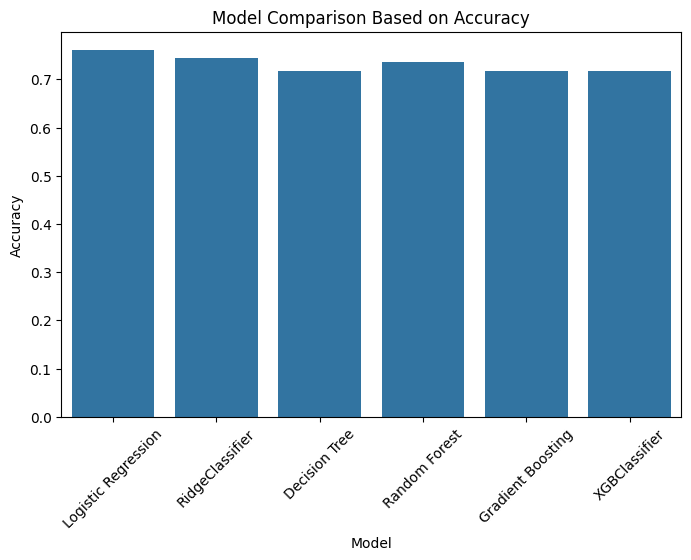

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=model_results)
plt.xticks(rotation=45)
plt.title("Model Comparison Based on Accuracy")
plt.show()


### BEST MODEL SELECTION
Based on model comparison results, Logistic Regression was selected as the final model for deployment due to its highest accuracy and interpretability.



In [62]:
best_model = model_results.loc[model_results["Accuracy"].idxmax()]
best_model


,0
Model,Logistic Regression
Accuracy,0.760684


In [63]:
print("Best Model:")
print(best_model)


Best Model:
Model       Logistic Regression
Accuracy               0.760684
Name: 0, dtype: object


In [64]:
final_model = LogisticRegression(max_iter=1000, penalty='l2')
final_model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [65]:
y_pred_final = final_model.predict(x_test)

print("Final Model: Logistic Regression")
print(classification_report(y_test, y_pred_final))
print("Accuracy:", accuracy_score(y_test, y_pred_final))

Final Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.56      0.30      0.39        30
           1       0.79      0.92      0.85        87

    accuracy                           0.76       117
   macro avg       0.68      0.61      0.62       117
weighted avg       0.73      0.76      0.73       117

Accuracy: 0.7606837606837606


In [66]:
import joblib
joblib.dump(final_model, "logistic_liver_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [68]:
df


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Disease
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,1


### USER INPUT PREDICTION
A user input function was created where users can enter medical parameters such as bilirubin levels and enzyme values. The trained model predicts whether the patient has liver disease.

### Notes:
* Inputs are scaled using the trained scaler
* Prediction and probability are displayed
* This simulates real-world application




In [69]:
def get_user_input():
    age = float(input("Enter Age: "))
    gender = input("Enter Gender (Male/Female): ").strip().lower()

    total_bilirubin = float(input("Enter Total Bilirubin: "))
    direct_bilirubin = float(input("Enter Direct Bilirubin: "))
    alkaline_phosphotase = float(input("Enter Alkaline Phosphotase: "))
    alamine_aminotransferase = float(input("Enter Alamine Aminotransferase (ALT): "))
    aspartate_aminotransferase = float(input("Enter Aspartate Aminotransferase (AST): "))
    total_proteins = float(input("Enter Total Proteins: "))
    albumin = float(input("Enter Albumin: "))
    ag_ratio = float(input("Enter Albumin and Globulin Ratio: "))

    gender = 1 if gender == "male" else 0

    user_data = np.array([[age, gender, total_bilirubin, direct_bilirubin,
                            alkaline_phosphotase, alamine_aminotransferase,
                            aspartate_aminotransferase, total_proteins,
                            albumin, ag_ratio]])
    return user_data


user_input = get_user_input()
user_input_scaled = scaler.transform(user_input)

prediction = final_model.predict(user_input_scaled)
probability = final_model.predict_proba(user_input_scaled)

if prediction[0] == 1:
    print("Patient is likely to have Liver Disease")
else:
    print("Patient is NOT likely to have Liver Disease")

print("Prediction Probability:", probability)


Enter Age: 40
Enter Gender (Male/Female): Male
Enter Total Bilirubin: 3.9
Enter Direct Bilirubin: 2.0
Enter Alkaline Phosphotase: 200
Enter Alamine Aminotransferase (ALT): 60
Enter Aspartate Aminotransferase (AST): 20
Enter Total Proteins: 6.8
Enter Albumin: 3.3
Enter Albumin and Globulin Ratio: 0.90
Patient is likely to have Liver Disease
Prediction Probability: [[0.22912363 0.77087637]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### **CHALLENGES FACED**:

* The main challenges faced in this project were the presence of outliers and high correlation among medical features. These issues could not be resolved by removing variables, as it reduced dataset size and negatively affected model accuracy.

* Additionally, class imbalance and feature selection posed challenges in achieving balanced model performance. Careful evaluation and retention of medically important features helped overcome these challenges.




### **CONCLUSION**:

In this project, a machine learning based classification system was developed to predict liver disease using the Indian Liver Patient Dataset. The dataset was thoroughly analyzed through data exploration, visualization, feature encoding, and feature importance analysis.

Several classification models, including traditional machine learning algorithms and XGBoost, were trained and evaluated using standard performance metrics such as accuracy, confusion matrix, and classification report.

* The detected outliers represent extreme but valid medical conditions (severe liver disease cases) rather than data errors. Removing them would lead to loss of important clinical information.

* Many features are biologically related (for example, Total Bilirubin and Direct Bilirubin, ALT and AST, Albumin and Total Proteins), which naturally results in high correlation in medical datasets.

* When attempts were made to drop highly correlated or extreme-value features, the dataset size was reduced and model performance (accuracy) decreased.

* When attempts were made to drop highly correlated or extreme-value features, the dataset size was reduced and model performance (accuracy) decreased.

* The primary objective of this project was classification performance, not regression coefficient interpretation. Models such as Random Forest and XGBoost are less sensitive to multicollinearity and can effectively handle correlated features.

* Therefore, all features were retained to preserve medical significance and achieve better predictive performance.




